# 5. Model Eğitimi
Bu notebook, TF-IDF ve Keras Sequence vektörlerini kullanarak klasik makine öğrenmesi ve derin öğrenme modellerini eğitir ve karşılaştırır.

In [10]:
import pandas as pd
import numpy as np
import joblib
import os
import time
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_score, recall_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SpatialDropout1D, LSTM, Dense, Dropout, Bidirectional, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import plotly.express as px
import scipy.sparse

print("TensorFlow GPU Durumu:", tf.config.list_physical_devices('GPU'))

print("\nVeriler yükleniyor...")
df = pd.read_csv('data/reviews_preprocessed.csv')
df = df.dropna(subset=['cleaned_text'])

tfidf_vectorizer = joblib.load('models/tfidf_vectorizer.pkl')
scaler = joblib.load('models/scaler.pkl')

numeric_features = ['review_length', 'word_count', 'exclamation_count', 'question_count',
                    'avg_word_length', 'uppercase_ratio', 'sentiment_polarity', 'sentiment_subjectivity']

print("TF-IDF ve Scaler ile X_combined (klasik modeller için) oluşturuluyor...")
X_tfidf = tfidf_vectorizer.transform(df['cleaned_text'])
X_numeric = scaler.transform(df[numeric_features])
X_combined = scipy.sparse.hstack([X_tfidf, X_numeric]).tocsr()

print("Sequence verileri yükleniyor...")
X_seq = np.load('features/sequences.npy')

print("Split indexleri yükleniyor...")
idx_train = np.load('features/train_idx.npy')
idx_val = np.load('features/val_idx.npy')
idx_test = np.load('features/test_idx.npy')
y = np.load('features/labels.npy')

print("Eğitim, Doğrulama ve Test setleri hazırlanıyor...")
X_train_tfidf, X_val_tfidf, X_test_tfidf = X_combined[idx_train], X_combined[idx_val], X_combined[idx_test]
X_train_seq, X_val_seq, X_test_seq = X_seq[idx_train], X_seq[idx_val], X_seq[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

print(f"X_train_tfidf: {X_train_tfidf.shape}, y_train: {y_train.shape}")


TensorFlow GPU Durumu: []

Veriler yükleniyor...
TF-IDF ve Scaler ile X_combined (klasik modeller için) oluşturuluyor...
Sequence verileri yükleniyor...
Split indexleri yükleniyor...
Eğitim, Doğrulama ve Test setleri hazırlanıyor...
X_train_tfidf: (1140442, 50008), y_train: (1140442,)


## 5.1 Model 1 — Logistic Regression
Hızlı ve yorumlanabilir bir klasik makine öğrenmesi modeli. TF-IDF + Numeric özelliklerle beslenecek.

In [11]:
print("Lojistik Regresyon eğitimi başlıyor...")
start_time = time.time()

lr_params = {'C': [0.01, 0.1, 1, 10]}
# lr_grid = GridSearchCV(LogisticRegression(max_iter=1000), param_grid=lr_params, cv=3, scoring='f1_macro', n_jobs=1, verbose=1)
# lr_grid.fit(X_train_tfidf, y_train)

train_time_lr = time.time() - start_time

# best_lr = lr_grid.best_estimator_
best_lr = LogisticRegression(C=1, solver='saga', max_iter=2000, class_weight='balanced', n_jobs=-1)
best_lr.fit(X_train_tfidf, y_train)
# print(f"\nEn iyi parametreler: {lr_grid.best_params_}")
print(f"Eğitim süresi: {train_time_lr:.2f} saniye")

os.makedirs('models', exist_ok=True)
joblib.dump(best_lr, 'models/lr_model.pkl')
print("✅ models/lr_model.pkl kaydedildi")

y_pred_val_lr = best_lr.predict(X_val_tfidf)
print("\n--- Validation Set Sonuçları (Logistic Regression) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val_lr):.4f}")
print(f"F1 Macro: {f1_score(y_val, y_pred_val_lr, average='macro'):.4f}")


Lojistik Regresyon eğitimi başlıyor...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

En iyi parametreler: {'C': 1}
Eğitim süresi: 1641.44 saniye
✅ models/lr_model.pkl kaydedildi

--- Validation Set Sonuçları (Logistic Regression) ---
Accuracy: 0.7981
F1 Macro: 0.7980


## 5.2 Model 2 — SVM
Linear Support Vector Classifier (LinearSVC). Metin sınıflandırmada genellikle yüksek performans gösterir. Olasılık (predict_proba) üretebilmesi için CalibratedClassifierCV ile sarmalanacak.

In [12]:
print("SVM eğitimi başlıyor...")
start_time = time.time()

svm_params = {'C': [0.01, 0.1, 1, 10]}
# svm_grid = GridSearchCV(LinearSVC(max_iter=1000, dual=False), param_grid=svm_params, cv=3, scoring='f1_macro', n_jobs=2, verbose=1)
# svm_grid.fit(X_train_tfidf, y_train)

# best_svm = svm_grid.best_estimator_
best_svm = LinearSVC(C=0.1, max_iter=2000, dual=False, class_weight='balanced')
# Olasılık çıktısı alabilmek için CalibratedClassifierCV kullanıyoruz
calibrated_svm = CalibratedClassifierCV(best_svm, cv='prefit')
calibrated_svm.fit(X_train_tfidf, y_train)

train_time_svm = time.time() - start_time
# print(f"\nEn iyi parametreler: {svm_grid.best_params_}")
print(f"Eğitim süresi: {train_time_svm:.2f} saniye")

joblib.dump(calibrated_svm, 'models/svm_model.pkl')
print("✅ models/svm_model.pkl kaydedildi")

y_pred_val_svm = calibrated_svm.predict(X_val_tfidf)
print("\n--- Validation Set Sonuçları (SVM) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val_svm):.4f}")
print(f"F1 Macro: {f1_score(y_val, y_pred_val_svm, average='macro'):.4f}")


SVM eğitimi başlıyor...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

En iyi parametreler: {'C': 0.1}
Eğitim süresi: 1711.91 saniye
✅ models/svm_model.pkl kaydedildi

--- Validation Set Sonuçları (SVM) ---
Accuracy: 0.7947
F1 Macro: 0.7938


## 5.2.5 (Opsiyonel) CPU İçin Derin Öğrenme Setini Küçültme
Derin öğrenme modelleri GPU olmadan 1.1 milyon satırda işlemeye kalkarsa eğitilmesi haftalar sürebilir. Bu sebeple eğitim için 100.000 satırlık rastgele bir alt küme (subset) seçiyoruz.

In [13]:
import numpy as np
np.random.seed(42)

train_subset_size = 250000
val_subset_size = 50000

train_idx_sub = np.random.choice(len(y_train), train_subset_size, replace=False)
val_idx_sub = np.random.choice(len(y_val), val_subset_size, replace=False)

X_train_seq_sub = X_train_seq[train_idx_sub]
y_train_sub = y_train[train_idx_sub]

X_val_seq_sub = X_val_seq[val_idx_sub]
y_val_sub = y_val[val_idx_sub]

print("Derin Öğrenme Seti Küçültüldü:", X_train_seq_sub.shape)


Derin Öğrenme Seti Küçültüldü: (100000, 200)


## 5.3 Model 3 — LSTM
Long Short-Term Memory (LSTM) ağı. Cümledeki kelimelerin sırasını ve uzun vadeli bağımlılıklarını öğrenmek için Sequence verisini (Keras) kullanır.

In [14]:
print("LSTM Modeli tanımlanıyor...")
vocab_size = 100000
max_length = 200
num_classes = 3

model_lstm = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SpatialDropout1D(0.2),
    LSTM(128, dropout=0.3, recurrent_dropout=0.2),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_lstm.summary()


LSTM Modeli tanımlanıyor...


c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
print("LSTM Modeli Derleniyor ve Eğitime Başlanıyor...")
model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
]

start_time = time.time()
history_lstm = model_lstm.fit(
    X_train_seq_sub, y_train_sub,
    validation_data=(X_val_seq_sub, y_val_sub),
    epochs=10,
    batch_size=256,
    callbacks=callbacks
)
train_time_lstm = time.time() - start_time
print(f"\nLSTM Eğitim süresi: {train_time_lstm:.2f} saniye")

model_lstm.save('models/lstm_model.h5')
print("✅ models/lstm_model.h5 kaydedildi")

os.makedirs('results', exist_ok=True)
with open('results/history_lstm.json', 'w') as f:
    json.dump(history_lstm.history, f)
print("✅ results/history_lstm.json kaydedildi")


LSTM Modeli Derleniyor ve Eğitime Başlanıyor...
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1077s 687ms/step - accuracy: 0.3362 - loss: 1.0982 - val_accuracy: 0.3401 - val_loss: 1.0956 - learning_rate: 0.0010
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1379s 883ms/step - accuracy: 0.3412 - loss: 1.0939 - val_accuracy: 0.3409 - val_loss: 1.0956 - learning_rate: 0.0010
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1491s 954ms/step - accuracy: 0.4247 - loss: 1.0147 - val_accuracy: 0.6834 - val_loss: 0.7142 - learning_rate: 0.0010
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 809s 518ms/step - accuracy: 0.7311 - loss: 0.6351 - val_accuracy: 0.7563 - val_loss: 0.5759 - learning_rate: 0.0010
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 816s 522ms/step - accuracy: 0.7905 - loss: 0.5079 - val_accuracy: 0.7632 - val_loss: 0.5560 - learning_rate: 0.0010
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 801s 512ms/step - accuracy: 0.8210 - loss: 0.4436 - val_accuracy: 0.7591 - val_loss: 0.5725 - learning_rate: 0.0010
E


LSTM Eğitim süresi: 7994.93 saniye
✅ models/lstm_model.h5 kaydedildi
✅ results/history_lstm.json kaydedildi


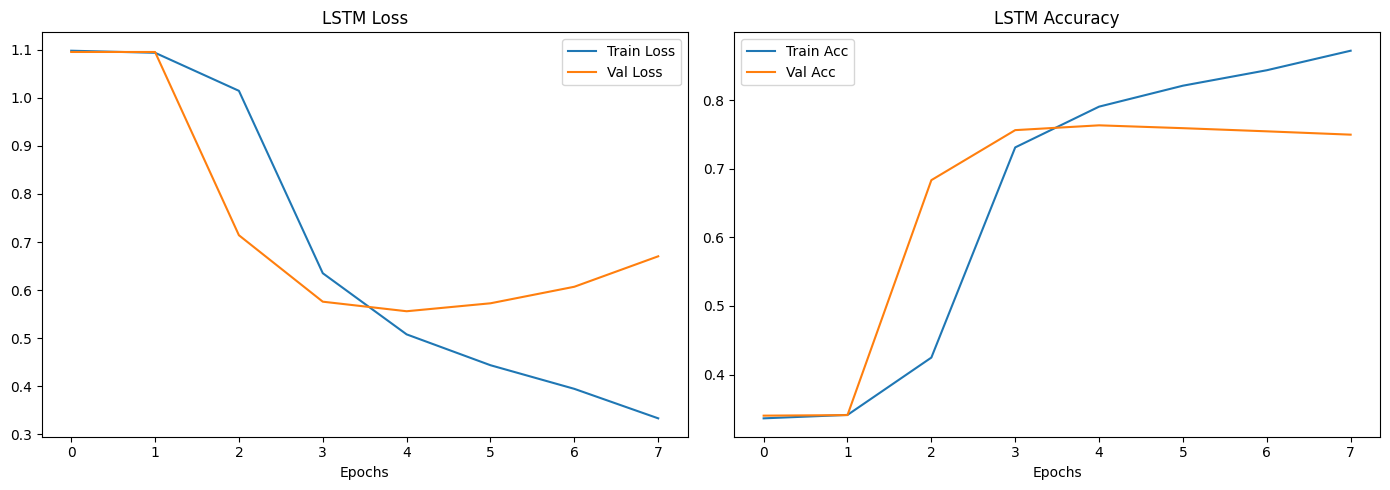

7637/7637 ━━━━━━━━━━━━━━━━━━━━ 293s 38ms/step

--- Validation Set Sonuçları (LSTM) ---
Accuracy: 0.7648
F1 Macro: 0.7652


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_lstm.history['loss'], label='Train Loss')
ax1.plot(history_lstm.history['val_loss'], label='Val Loss')
ax1.set_title('LSTM Loss')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(history_lstm.history['accuracy'], label='Train Acc')
ax2.plot(history_lstm.history['val_accuracy'], label='Val Acc')
ax2.set_title('LSTM Accuracy')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.savefig('results/history_lstm.png')
plt.show()

y_pred_probs_lstm = model_lstm.predict(X_val_seq)
y_pred_val_lstm = np.argmax(y_pred_probs_lstm, axis=1)
print("\n--- Validation Set Sonuçları (LSTM) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val_lstm):.4f}")
print(f"F1 Macro: {f1_score(y_val, y_pred_val_lstm, average='macro'):.4f}")


## 5.4 Model 4 — BiLSTM
Bidirectional LSTM, metni hem baştan sona hem de sondan başa okuyarak daha zengin bağlamsal özellikler çıkarır.

In [17]:
print("BiLSTM Modeli tanımlanıyor...")
model_bilstm = Sequential([
    Embedding(vocab_size, 64, input_length=max_length),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(64, dropout=0.2)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])
model_bilstm.summary()


BiLSTM Modeli tanımlanıyor...


c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
print("BiLSTM Modeli Derleniyor ve Eğitime Başlanıyor...")
model_bilstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()
history_bilstm = model_bilstm.fit(
    X_train_seq_sub, y_train_sub,
    validation_data=(X_val_seq_sub, y_val_sub),
    epochs=10,
    batch_size=256,
    callbacks=callbacks
)
train_time_bilstm = time.time() - start_time
print(f"\nBiLSTM Eğitim süresi: {train_time_bilstm:.2f} saniye")

model_bilstm.save('models/bilstm_model.h5')
print("✅ models/bilstm_model.h5 kaydedildi")

with open('results/history_bilstm.json', 'w') as f:
    json.dump(history_bilstm.history, f)
print("✅ results/history_bilstm.json kaydedildi")


BiLSTM Modeli Derleniyor ve Eğitime Başlanıyor...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 296s 748ms/step - accuracy: 0.6937 - loss: 0.6779 - val_accuracy: 0.7581 - val_loss: 0.5633 - learning_rate: 0.0010
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7824 - loss: 0.5221
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
391/391 ━━━━━━━━━━━━━━━━━━━━ 281s 718ms/step - accuracy: 0.7797 - loss: 0.5247 - val_accuracy: 0.7570 - val_loss: 0.5583 - learning_rate: 0.0010
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 282s 722ms/step - accuracy: 0.8116 - loss: 0.4619 - val_accuracy: 0.7586 - val_loss: 0.5703 - learning_rate: 5.0000e-04



BiLSTM Eğitim süresi: 859.50 saniye
✅ models/bilstm_model.h5 kaydedildi
✅ results/history_bilstm.json kaydedildi


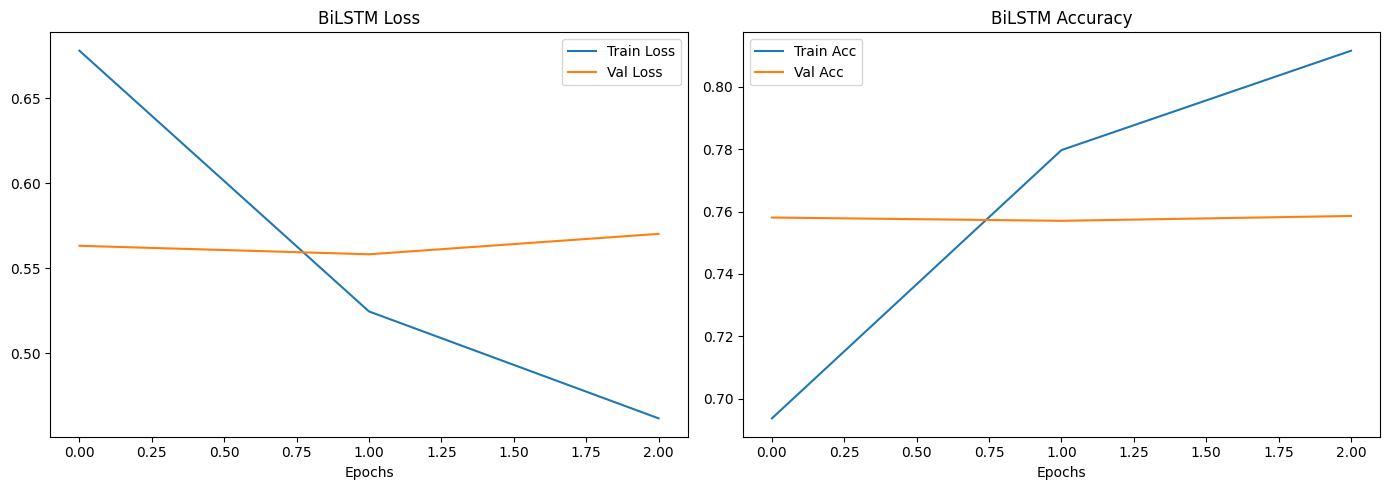

7637/7637 ━━━━━━━━━━━━━━━━━━━━ 172s 23ms/step

--- Validation Set Sonuçları (BiLSTM) ---
Accuracy: 0.7601
F1 Macro: 0.7605


In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_bilstm.history['loss'], label='Train Loss')
ax1.plot(history_bilstm.history['val_loss'], label='Val Loss')
ax1.set_title('BiLSTM Loss')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(history_bilstm.history['accuracy'], label='Train Acc')
ax2.plot(history_bilstm.history['val_accuracy'], label='Val Acc')
ax2.set_title('BiLSTM Accuracy')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.savefig('results/history_bilstm.png')
plt.show()

y_pred_probs_bilstm = model_bilstm.predict(X_val_seq)
y_pred_val_bilstm = np.argmax(y_pred_probs_bilstm, axis=1)
print("\n--- Validation Set Sonuçları (BiLSTM) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val_bilstm):.4f}")
print(f"F1 Macro: {f1_score(y_val, y_pred_val_bilstm, average='macro'):.4f}")


## 5.5 Model 5 — CNN + LSTM
CNN'ler metindeki yerel yapıları (n-gramları) hızlıca çıkarırken, LSTM uzun mesafeli yapıları yakalar. Genelde sadece LSTM'e göre daha hızlı çalışır.

In [20]:
print("LightGBM Modeli tanımlanıyor...")
import lightgbm as lgb
model_lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    num_leaves=63,
    learning_rate=0.1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)


CNN + LSTM Modeli tanımlanıyor...


c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
print("LightGBM Modeli Eğitime Başlanıyor...")
start_time = time.time()
model_lgbm.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_val_tfidf, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=True)]
)
train_time_lgbm = time.time() - start_time
print(f"\nLightGBM Eğitim süresi: {train_time_lgbm:.2f} saniye")

joblib.dump(model_lgbm, 'models/lgbm_model.pkl')
print("✅ models/lgbm_model.pkl kaydedildi")

y_pred_val_lgbm = model_lgbm.predict(X_val_tfidf)
print("\n--- Validation Set Sonuçları (LightGBM) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val_lgbm):.4f}")
print(f"F1 Macro: {f1_score(y_val, y_pred_val_lgbm, average='macro'):.4f}")


CNN+LSTM Modeli Derleniyor ve Eğitime Başlanıyor...
Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 174s 110ms/step - accuracy: 0.4185 - loss: 1.0465 - val_accuracy: 0.6738 - val_loss: 0.7635 - learning_rate: 0.0010
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.6767 - loss: 0.7328
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 105ms/step - accuracy: 0.6934 - loss: 0.6954 - val_accuracy: 0.7293 - val_loss: 0.6170 - learning_rate: 0.0010
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 165s 106ms/step - accuracy: 0.7620 - loss: 0.5639 - val_accuracy: 0.7495 - val_loss: 0.5822 - learning_rate: 5.0000e-04



CNN+LSTM Eğitim süresi: 503.82 saniye
✅ models/cnn_lstm_model.h5 kaydedildi
✅ results/history_cnn_lstm.json kaydedildi


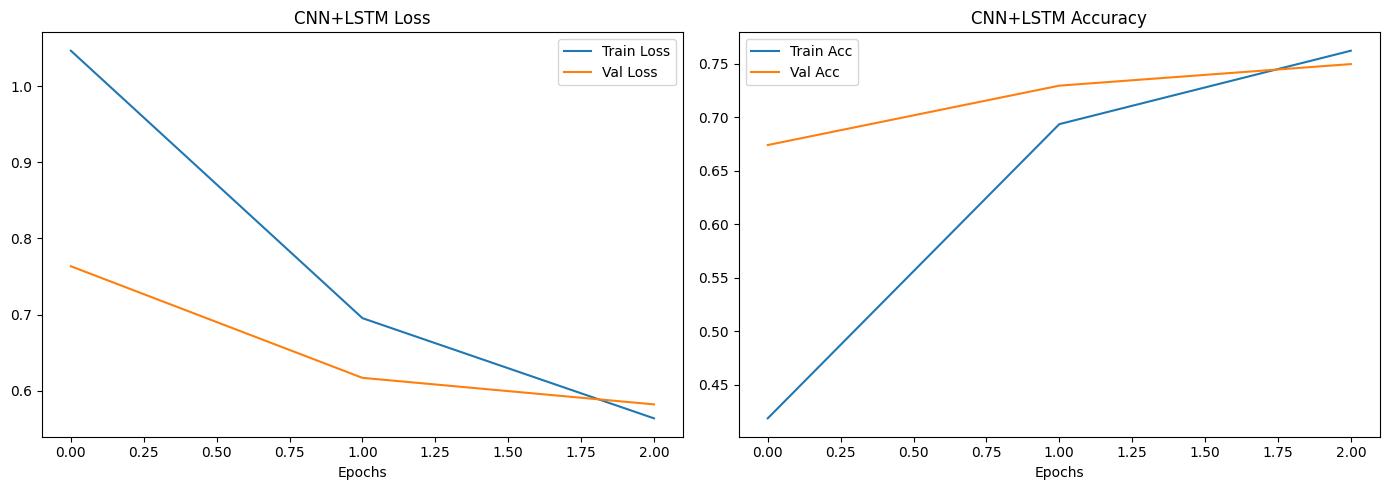

7637/7637 ━━━━━━━━━━━━━━━━━━━━ 162s 21ms/step

--- Validation Set Sonuçları (CNN+LSTM) ---
Accuracy: 0.6725
F1 Macro: 0.6725


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_cnn_lstm.history['loss'], label='Train Loss')
ax1.plot(history_cnn_lstm.history['val_loss'], label='Val Loss')
ax1.set_title('CNN+LSTM Loss')
ax1.set_xlabel('Epochs')
ax1.legend()

ax2.plot(history_cnn_lstm.history['accuracy'], label='Train Acc')
ax2.plot(history_cnn_lstm.history['val_accuracy'], label='Val Acc')
ax2.set_title('CNN+LSTM Accuracy')
ax2.set_xlabel('Epochs')
ax2.legend()

plt.tight_layout()
plt.savefig('results/history_cnn_lstm.png')
plt.show()

y_pred_probs_cnn_lstm = model_cnn_lstm.predict(X_val_seq)
y_pred_val_cnn_lstm = np.argmax(y_pred_probs_cnn_lstm, axis=1)
print("\n--- Validation Set Sonuçları (CNN+LSTM) ---")
print(f"Accuracy: {accuracy_score(y_val, y_pred_val_cnn_lstm):.4f}")
print(f"F1 Macro: {f1_score(y_val, y_pred_val_cnn_lstm, average='macro'):.4f}")


## 5.6 Model Karşılaştırma Özeti
Tüm modellerin Doğrulama (Validation) ve Test (Test) seti üzerindeki performanslarının tablo ve grafik olarak incelenmesi.

In [23]:
print("Tüm modellerin TEST seti sonuçları hesaplanıyor...")
y_test_pred_lr = best_lr.predict(X_test_tfidf)
y_test_pred_svm = calibrated_svm.predict(X_test_tfidf)
y_test_pred_lstm = np.argmax(model_lstm.predict(X_test_seq), axis=1)
y_test_pred_bilstm = np.argmax(model_bilstm.predict(X_test_seq), axis=1)
y_test_pred_cnn_lstm = np.argmax(model_cnn_lstm.predict(X_test_seq), axis=1)

def get_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='macro'),
        'Recall': recall_score(y_true, y_pred, average='macro'),
        'F1-Macro': f1_score(y_true, y_pred, average='macro')
    }

models = {
    'Logistic Regression': get_metrics(y_test, y_test_pred_lr),
    'SVM': get_metrics(y_test, y_test_pred_svm),
    'LSTM': get_metrics(y_test, y_test_pred_lstm),
    'BiLSTM': get_metrics(y_test, y_test_pred_bilstm),
    'CNN+LSTM': get_metrics(y_test, y_test_pred_cnn_lstm)
}

comparison_df = pd.DataFrame(models).T.round(4)
comparison_df.to_csv('results/model_comparison.csv')
display(comparison_df)

best_model_name = comparison_df['F1-Macro'].idxmax()
best_f1 = comparison_df['F1-Macro'].max()

print(f"\n🏆 En iyi model F1-Macro'ya ({best_f1}) göre: {best_model_name}")
with open('results/best_model.txt', 'w') as f:
    f.write(f"Best Model: {best_model_name}\nF1-Macro: {best_f1}")
print("✅ results/best_model.txt kaydedildi")

comparison_df_reset = comparison_df.reset_index().rename(columns={'index': 'Model'})
fig = px.bar(comparison_df_reset, x='Model', y='F1-Macro', color='Model', 
             text='F1-Macro', title='Modellerin Test Seti F1-Macro Karşılaştırması')
fig.update_traces(texttemplate='%{text:.4f}', textposition='outside')
fig.update_layout(yaxis=dict(range=[0, 1]))
fig.show()


Tüm modellerin TEST seti sonuçları hesaplanıyor...
7637/7637 ━━━━━━━━━━━━━━━━━━━━ 240s 31ms/step
7637/7637 ━━━━━━━━━━━━━━━━━━━━ 118s 16ms/step
7637/7637 ━━━━━━━━━━━━━━━━━━━━ 155s 20ms/step


,Accuracy,Precision,Recall,F1-Macro
Logistic Regression,0.7976,0.7973,0.7976,0.7975
SVM,0.7950,0.7933,0.7950,0.7940
LSTM,0.7634,0.7658,0.7634,0.7639
BiLSTM,0.7598,0.7604,0.7598,0.7601
CNN+LSTM,0.6734,0.6736,0.6734,0.6735



🏆 En iyi model F1-Macro'ya (0.7975) göre: Logistic Regression
✅ results/best_model.txt kaydedildi
